This NB tests the algorithm on time series data such that y[i] = f(x[i-1])

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [249]:
#setting up time array and random seed
domain = 8000
step = 0.1
t = np.arange(0, domain, step)

np.random.seed(42)

In [873]:
#setting up feature functions and adding random gaussian noise
noise_mf = 30
x1c = 210
x2c = 19
x3c = 100
x4c = 22
x1 = 210 * np.sin(2 * 3.14 * 0.005 * t) + 12 * np.cos(2 * 3.14 * 0.001 * t) + np.random.normal(0,x1c * noise_mf / 100, size=t.shape)

x2 = 19 * np.sign(np.sin(2 * np.pi * 0.001 * t)) + np.random.normal(0, x2c * noise_mf / 100, size=t.shape)

x3 = 100 * (t * 0.0055 - np.floor(0.5 + t * 0.0055)) + np.random.normal(0, x3c * noise_mf / 100, size=t.shape)

x4 = 22 * np.arcsin(np.sin(2 * np.pi * 0.0025 * t)) / np.pi + np.random.normal(0, x4c * noise_mf / 100, size=t.shape)

x5 = np.random.normal(1, 5, size=t.shape) #dc offset

In [875]:
#setting up the label curve
def generate_signal(t):

    # Initialize signal array
    y = np.zeros_like(t)

    # Lag-1 dependency: start from index 1
    y[1:] = x1[:-1] + x2[:-1] + x3[:-1] + x4[:-1] + x5[:-1]

    # Optional: first value can be set to 0 or same as t=0
    y[0] = x1[0] + x2[0] + x3[0] + x4[0] + x5[0]

    return y

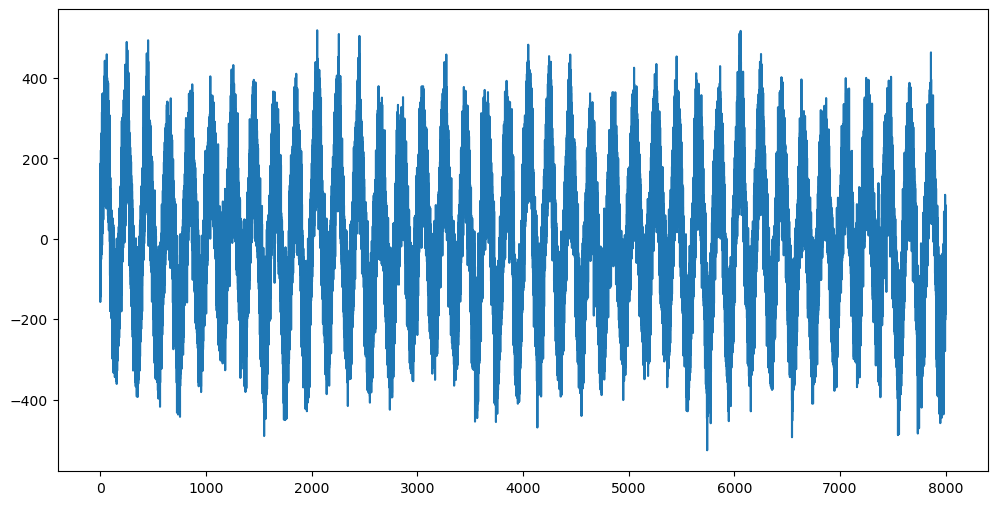

In [877]:
#creating signal by reversing and replicating generated base curve
signal = generate_signal(t)
#inv_base_signal = np.flip(base_signal)

#time = np.arange(0, 8 * domain, step)
#intermediate_signal = np.concatenate((base_signal, inv_base_signal))
segment1 = intermediate_signal + np.random.normal(0,5, size = intermediate_signal.shape)
segment2 = intermediate_signal + np.random.normal(0,5, size = intermediate_signal.shape)
segment3 = intermediate_signal + np.random.normal(0,5, size = intermediate_signal.shape)
segment4 = intermediate_signal + np.random.normal(0,5, size = intermediate_signal.shape)

#signal = np.concatenate((segment1, segment2, segment3, segment4))
plt.figure(figsize=(12, 6))
plt.plot(t, signal)



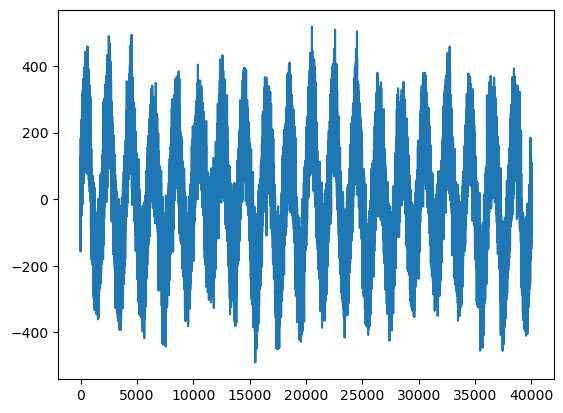

In [879]:
split_point = len(signal) // 2
signal_train = signal[0:split_point]
signal_test = signal[split_point:]

plt.plot(signal_train)

[  4504.14027712 -8615.03753975j  -2689.03852071 -2352.21220899j
  -2414.46225711 -2339.03301564j ...  -6836.477417  -16176.20496311j
 -10992.79123269-12780.66443246j -12105.15783265+10905.43211928j]


/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


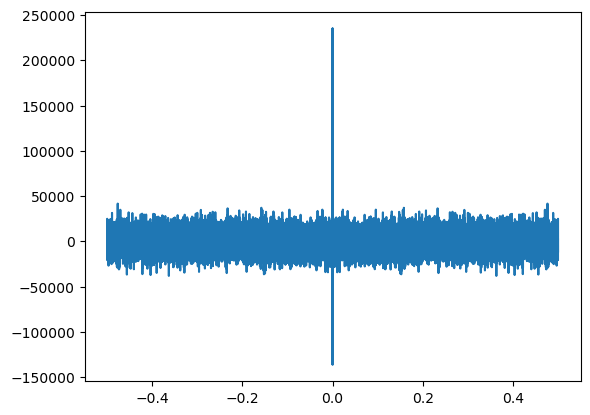

In [881]:
Y_fft = np.fft.fft(signal_train)
freqs = np.fft.fftfreq(len(signal_train), 1)
pos_mask = freqs >= 0
Y_fft_pos = Y_fft[pos_mask]
freqs_pos = freqs[pos_mask]
print(Y_fft_pos[freqs_pos > 0.06])

plt.plot(freqs, Y_fft) 
#plt.xlim(-0.02,0.02)

/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


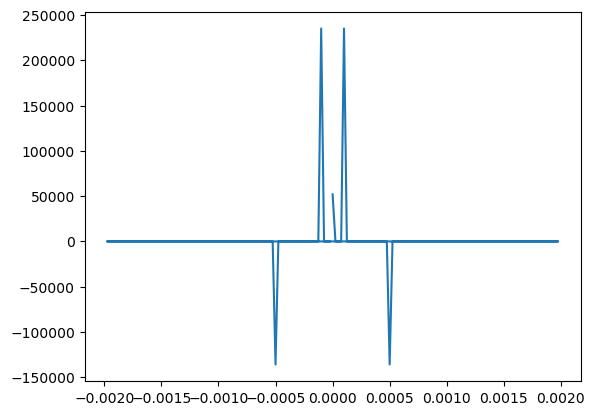

In [897]:
threshold = 0.002
mag_threshold = 50000
lpf_mask = np.abs(freqs) < threshold
Y_fft_lpf = Y_fft * lpf_mask
freqs_lpf = freqs * lpf_mask
mag_mask = np.abs(Y_fft_lpf.real) > mag_threshold
Y_fft_lpf_mf = Y_fft_lpf * mag_mask
plt.plot(freqs_lpf, Y_fft_lpf_mf)

In [909]:
y_time_domain = np.fft.ifft(Y_fft_lpf).real

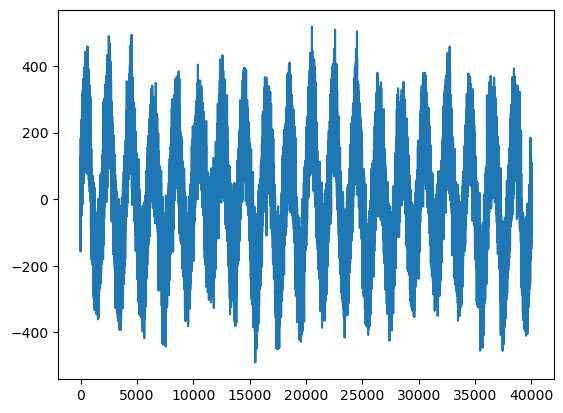

In [911]:
plt.plot(y_time_domain)

In [913]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error, median_absolute_error, explained_variance_score, max_error

def regression_comparison_table(y_true, y_dnn, y_opt):
    
    def compute_metrics(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        medae = median_absolute_error(y_true, y_pred)
        evs = explained_variance_score(y_true, y_pred)
        maxe = max_error(y_true, y_pred)

        return {
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "MedAE": medae,
            "ExplainedVariance": evs,
            "MaxError": maxe
        }

    dnn_metrics = compute_metrics(y_true, y_dnn)
    opt_metrics = compute_metrics(y_true, y_opt)

    print("\nRegression Model Comparison\n")

    header = f"{'Metric':<20}{'DNN':>15}{'Optimizer':>15}"
    print(header)
    print("-" * len(header))

    for key in dnn_metrics:
        print(f"{key:<20}{dnn_metrics[key]:>15.6f}{opt_metrics[key]:>15.6f}", '             ', np.abs(dnn_metrics[key] - opt_metrics[key]))

    return dnn_metrics, opt_metrics

In [915]:
model_comparator = regression_comparison_table(signal_test, signal_train, y_time_domain)


Regression Model Comparison

Metric                          DNN      Optimizer
--------------------------------------------------
RMSE                     100.490724     100.490724               1.4210854715202004e-14
MAE                       80.160269      80.160269               1.4210854715202004e-14
R2                         0.655871       0.655871               0.0
MedAE                     67.574602      67.574602               1.4210854715202004e-14
ExplainedVariance          0.655894       0.655894               1.1102230246251565e-16
MaxError                 459.485274     459.485274               0.0


0.005
0.8232349649838605


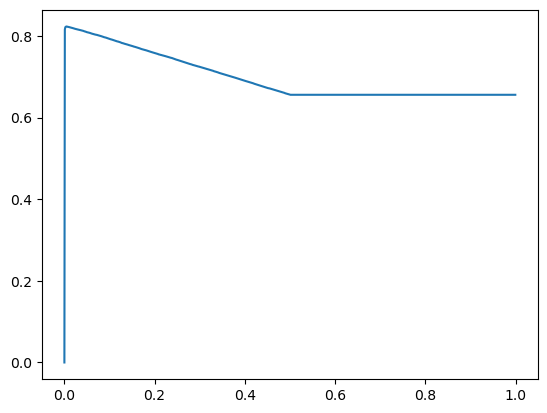

In [917]:
r2_scores = []
max_score = 0
best_threshold = 0
for i in np.arange(0,1,0.001):
    threshold = i
    lpf_mask = np.abs(freqs) < threshold
    Y_fft_lpf = Y_fft * lpf_mask
    y_time_domain = np.fft.ifft(Y_fft_lpf).real
    r_score   = r2_score(signal_test, y_time_domain)
    r2_scores.append(r_score)
    if r_score > max_score:
        max_score = r_score
        best_threshold = i
print(best_threshold)
print(max_score)
plt.plot(np.arange(0,1,0.001), r2_scores)

